In [1]:
!pip install imbalanced-learn

In [2]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from imblearn.over_sampling import SMOTE

import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("wineQT.csv")

# Drop ID column
df = df.drop('Id', axis=1)

In [4]:
df['quality'] = df['quality'].apply(lambda x: 1 if x >= 7 else 0)

In [5]:
X = df.drop('quality', axis=1)
y = df['quality']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [7]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [8]:
smote = SMOTE(random_state=42)

X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", np.bincount(y_train))
print("After SMOTE:", np.bincount(y_train_sm))

Before SMOTE: [787 127]
After SMOTE: [787 787]


In [9]:
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train_sm, y_train_sm)

rf_pred = rf.predict(X_test)

In [10]:
rf = RandomForestClassifier(class_weight='balanced', random_state=42)

rf.fit(X_train_sm, y_train_sm)

rf_pred = rf.predict(X_test)

In [11]:
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("\nClassification Report:\n", classification_report(y_test, rf_pred))

Accuracy: 0.8908296943231441

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.93      0.94       197
           1       0.61      0.62      0.62        32

    accuracy                           0.89       229
   macro avg       0.77      0.78      0.78       229
weighted avg       0.89      0.89      0.89       229



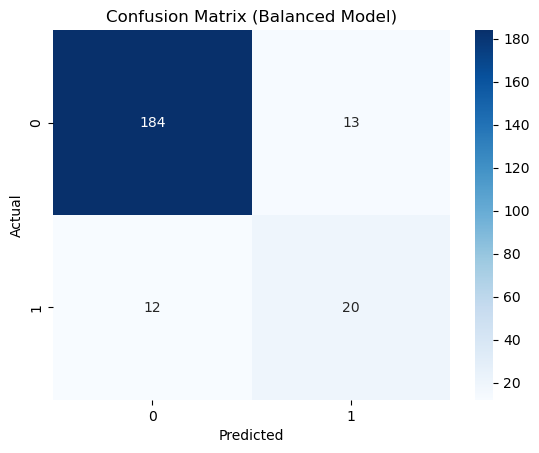

In [12]:
cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Balanced Model)")
plt.show()

In [13]:
from sklearn.svm import SVC

svc = SVC()

svc.fit(X_train_sm, y_train_sm)

svc_pred = svc.predict(X_test)

print(classification_report(y_test, svc_pred))

              precision    recall  f1-score   support

           0       0.94      0.87      0.90       197
           1       0.45      0.66      0.53        32

    accuracy                           0.84       229
   macro avg       0.69      0.76      0.72       229
weighted avg       0.87      0.84      0.85       229



In [14]:
def predict_wine_quality(model, scaler, input_data):
    # Convert input into DataFrame
    input_df = pd.DataFrame([input_data])
    
    # Scale input
    input_scaled = scaler.transform(input_df)
    
    # Predict
    prediction = model.predict(input_scaled)
    
    # Convert to label
    result = "Good" if prediction[0] == 1 else "Bad"
    
    return result

In [15]:
sample_input = {
    'fixed acidity': 7.4,
    'volatile acidity': 0.70,
    'citric acid': 0.00,
    'residual sugar': 1.9,
    'chlorides': 0.076,
    'free sulfur dioxide': 11.0,
    'total sulfur dioxide': 34.0,
    'density': 0.9978,
    'pH': 3.51,
    'sulphates': 0.56,
    'alcohol': 9.4
}

In [16]:
result = predict_wine_quality(rf, scaler, sample_input)

print("Predicted Wine Quality:", result)

Predicted Wine Quality: Bad


In [18]:
def predict_with_probability(model, scaler, input_data):
    input_df = pd.DataFrame([input_data])
    input_scaled = scaler.transform(input_df)
    
    prediction = model.predict(input_scaled)
    prob = model.predict_proba(input_scaled)
    
    result = "Good" if prediction[0] == 1 else "Bad"
    
    print("Prediction:", result)
    print("Probability [Bad, Good]:", prob[0])

In [19]:
good_sample = {
    'fixed acidity': 7.0,
    'volatile acidity': 0.3,
    'citric acid': 0.4,
    'residual sugar': 2.0,
    'chlorides': 0.05,
    'free sulfur dioxide': 15.0,
    'total sulfur dioxide': 40.0,
    'density': 0.996,
    'pH': 3.3,
    'sulphates': 0.7,
    'alcohol': 11.5
}

print(predict_wine_quality(rf, scaler, good_sample))

Good
